In [1]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt

In [2]:
TRAIN_IMAGES = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images"
TRAIN_LABELS = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"
VAL_IMAGES = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images"
VAL_LABELS = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels"

In [3]:
CLASS_NAMES = {
    1: "Longitudinal Crack",
    2: "Transverse Crack",
    3: "Alligator Crack",
    4: "Other Corruption",
    5: "Pothole"
}

In [4]:
class RDDDataset(Dataset):

    def __init__(self, image_dir, label_dir):

        self.image_dir = image_dir
        self.label_dir = label_dir

        self.images = sorted(os.listdir(image_dir))


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        label_path = os.path.join(
            self.label_dir,
            image_name.replace(".jpg", ".txt")
        )


        image = Image.open(image_path).convert("RGB")

        w, h = image.size


        boxes = []
        labels = []


        if os.path.exists(label_path):

            with open(label_path) as f:

                for line in f:

                    cls, xc, yc, bw, bh = map(
                        float,
                        line.strip().split()
                    )

                    EPSILON = 1e-3
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    x2 = (xc + bw/2) * w
                    y2 = (yc + bh/2) * h
                    
                    if (x2 - x1) < EPSILON or (y2 - y1) < EPSILON:
                        continue
                    
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls) + 1)


        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)


        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }
        
        image = F.to_tensor(image)
        return image, target

In [5]:
train_dataset = RDDDataset(
    TRAIN_IMAGES,
    TRAIN_LABELS
)

val_dataset = RDDDataset(
    VAL_IMAGES,
    VAL_LABELS
)

In [6]:
from torch.utils.data import Subset
import random

random.seed(42)

train_indices = random.sample(
    range(len(train_dataset)),
    10000
)

val_indices = random.sample(
    range(len(val_dataset)),
    2000
)

train_dataset_subset = Subset(
    train_dataset,
    train_indices
)

val_dataset_subset = Subset(
    val_dataset,
    val_indices
)

In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [8]:
train_loader = DataLoader(
    train_dataset_subset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset_subset,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

In [9]:
image, target = train_dataset[0]
print(target)

{'boxes': tensor([[ 13.9999,  69.9999, 197.9999,  99.0001],
        [ 95.0001, 113.9999, 120.0000, 272.0000]]), 'labels': tensor([2, 1]), 'image_id': tensor([0])}


In [10]:
print("Train Images:", len(train_dataset_subset))
print("Validation Images:", len(val_dataset_subset))
print("Iterations per Epoch:", len(train_loader))

Train Images: 10000
Validation Images: 2000
Iterations per Epoch: 2500


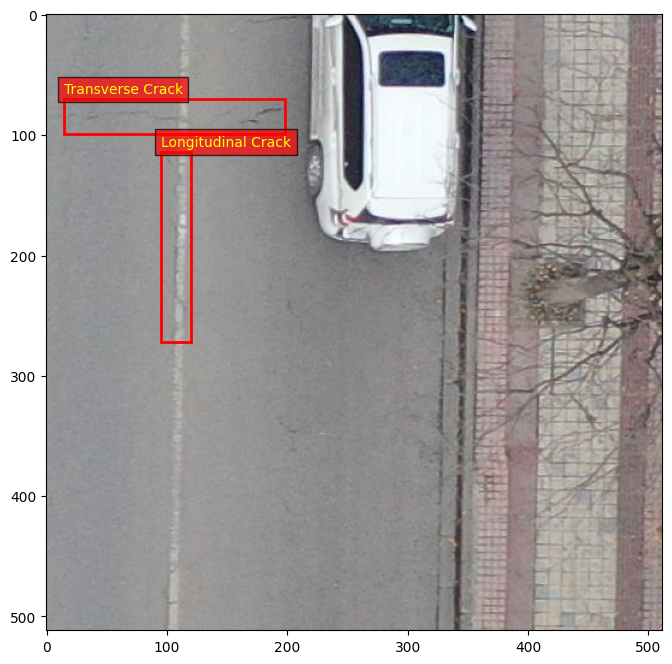

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image, target = train_dataset[0]

img = image.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)

for box, label in zip(target["boxes"], target["labels"]):

    x1, y1, x2, y2 = box.numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.text(
    x1,
    y1 - 5,
    CLASS_NAMES[label.item()],
    color='yellow',
    fontsize=10,
    bbox=dict(facecolor='red', alpha=0.7)
)
plt.show()

In [12]:
from torchvision.models.detection import (fasterrcnn_resnet50_fpn,FasterRCNN_ResNet50_FPN_Weights)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [13]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 213MB/s] 


In [14]:
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 6

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(in_features,num_classes)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [16]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [17]:
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [18]:
import time

train_losses = []

num_epochs = 10

for epoch in range(num_epochs):

    print(f"\n{'='*60}")
    print(f"Starting Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*60}", flush=True)

    start_time = time.time()

    model.train()
    epoch_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

        # Print every 100 batches
        if (batch_idx + 1) % 100 == 0:

            avg_loss = epoch_loss / (batch_idx + 1)

            print(
                f"Epoch [{epoch+1}/{num_epochs}] | "
                f"Batch [{batch_idx+1}/{len(train_loader)}] | "
                f"Batch Loss: {losses.item():.4f} | "
                f"Avg Loss: {avg_loss:.4f}",
                flush=True
            )

    lr_scheduler.step()

    epoch_time = time.time() - start_time

    train_losses.append(epoch_loss)

    torch.save(model.state_dict(),f"faster_rcnn_epoch_{epoch+1}.pth")

    print(f"\nEpoch {epoch+1} Complete")
    print(f"Total Loss: {epoch_loss:.4f}")
    print(f"Average Loss: {epoch_loss / len(train_loader):.4f}")
    print(f"Time Taken: {epoch_time/60:.2f} minutes")
    print(f"{'='*60}", flush=True)


Starting Epoch 1/10
Epoch [1/10] | Batch [100/2500] | Batch Loss: 0.2833 | Avg Loss: 0.3648
Epoch [1/10] | Batch [200/2500] | Batch Loss: 0.3451 | Avg Loss: 0.3449
Epoch [1/10] | Batch [300/2500] | Batch Loss: 0.1428 | Avg Loss: 0.3344
Epoch [1/10] | Batch [400/2500] | Batch Loss: 0.2105 | Avg Loss: 0.3288
Epoch [1/10] | Batch [500/2500] | Batch Loss: 0.7331 | Avg Loss: 0.3220
Epoch [1/10] | Batch [600/2500] | Batch Loss: 0.4111 | Avg Loss: 0.3171
Epoch [1/10] | Batch [700/2500] | Batch Loss: 0.3349 | Avg Loss: 0.3138
Epoch [1/10] | Batch [800/2500] | Batch Loss: 0.3761 | Avg Loss: 0.3120
Epoch [1/10] | Batch [900/2500] | Batch Loss: 0.2048 | Avg Loss: 0.3080
Epoch [1/10] | Batch [1000/2500] | Batch Loss: 0.1277 | Avg Loss: 0.3025
Epoch [1/10] | Batch [1100/2500] | Batch Loss: 0.2412 | Avg Loss: 0.2983
Epoch [1/10] | Batch [1200/2500] | Batch Loss: 0.3178 | Avg Loss: 0.2956
Epoch [1/10] | Batch [1300/2500] | Batch Loss: 0.3922 | Avg Loss: 0.2928
Epoch [1/10] | Batch [1400/2500] | Batc

In [20]:
!pip install torchmetrics pycocotools -q

In [21]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
def evaluate_map(model, dataloader, device):

    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox"
    )

    with torch.no_grad():

        for images, targets in dataloader:

            images = [img.to(device) for img in images]

            outputs = model(images)

            outputs_cpu = []

            for out in outputs:
                outputs_cpu.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu()
                })

            targets_cpu = []

            for t in targets:
                targets_cpu.append({
                    "boxes": t["boxes"].cpu(),
                    "labels": t["labels"].cpu()
                })

            metric.update(outputs_cpu, targets_cpu)

    return metric.compute()

In [22]:
results = {}

for epoch in range(1, 11):

    print(f"\nEvaluating Epoch {epoch}")

    model.load_state_dict(
        torch.load(
            f"/kaggle/working/faster_rcnn_epoch_{epoch}.pth"
        )
    )

    model.to(device)

    metrics = evaluate_map(
        model,
        val_loader,
        device
    )

    results[epoch] = metrics

    print(
        f"Epoch {epoch}: "
        f"mAP50={metrics['map_50']:.4f}, "
        f"mAP50-95={metrics['map']:.4f}"
    )


Evaluating Epoch 1
Epoch 1: mAP50=0.3806, mAP50-95=0.1650

Evaluating Epoch 2
Epoch 2: mAP50=0.4271, mAP50-95=0.1903

Evaluating Epoch 3
Epoch 3: mAP50=0.4111, mAP50-95=0.1835

Evaluating Epoch 4
Epoch 4: mAP50=0.4705, mAP50-95=0.2111

Evaluating Epoch 5
Epoch 5: mAP50=0.4620, mAP50-95=0.2021

Evaluating Epoch 6
Epoch 6: mAP50=0.5335, mAP50-95=0.2514

Evaluating Epoch 7
Epoch 7: mAP50=0.5359, mAP50-95=0.2528

Evaluating Epoch 8
Epoch 8: mAP50=0.5260, mAP50-95=0.2519

Evaluating Epoch 9
Epoch 9: mAP50=0.5267, mAP50-95=0.2495

Evaluating Epoch 10
Epoch 10: mAP50=0.5176, mAP50-95=0.2447


In [23]:
best_epoch = max(
    results,7
    key=lambda x: results[x]['map']
)

print(f"Best Epoch: {best_epoch}")
print(results[best_epoch])

Best Epoch: 7
{'map': tensor(0.2528), 'map_50': tensor(0.5359), 'map_75': tensor(0.2112), 'map_small': tensor(0.1090), 'map_medium': tensor(0.2110), 'map_large': tensor(0.2986), 'mar_1': tensor(0.2516), 'mar_10': tensor(0.4203), 'mar_100': tensor(0.4270), 'mar_small': tensor(0.2150), 'mar_medium': tensor(0.3793), 'mar_large': tensor(0.4729), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}


In [25]:
metrics = """
Faster R-CNN Final Results
==========================

Best Epoch: 7

mAP50: 0.5359
mAP50-95: 0.2528
mAP75: 0.2112

mAP Small: 0.1090
mAP Medium: 0.2110
mAP Large: 0.2986

Recall@1: 0.2516
Recall@10: 0.4203
Recall@100: 0.4270

Recall Small: 0.2150
Recall Medium: 0.3793
Recall Large: 0.4729
"""

with open("final_metrics.txt","w") as f:
    f.write(metrics)

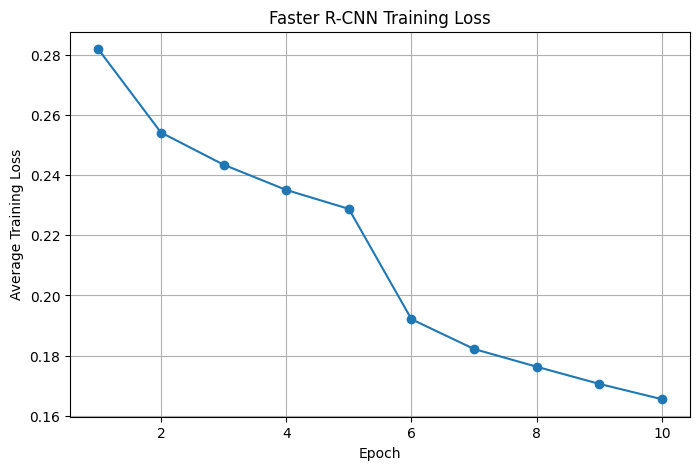

In [27]:
import matplotlib.pyplot as plt

epochs = list(range(1,11))

losses = [
    0.2819,
    0.2542,
    0.2435,
    0.2351,
    0.2288,
    0.1921,
    0.1822,
    0.1763,
    0.1706,
    0.1655
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Faster R-CNN Training Loss")

plt.grid(True)

plt.savefig("loss_curve.png",dpi=300,bbox_inches='tight'
)

plt.show()

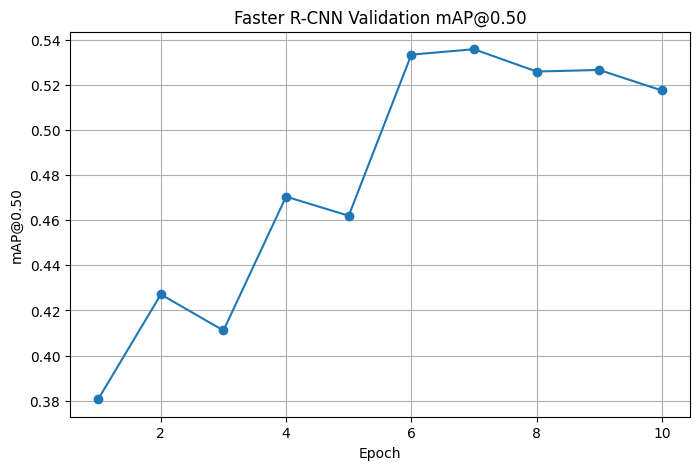

In [28]:
map50 = [
    0.3806,
    0.4271,
    0.4111,
    0.4705,
    0.4620,
    0.5335,
    0.5359,
    0.5260,
    0.5267,
    0.5176
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    map50,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("mAP@0.50")

plt.title("Faster R-CNN Validation mAP@0.50")

plt.grid(True)

plt.savefig(
    "map50_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

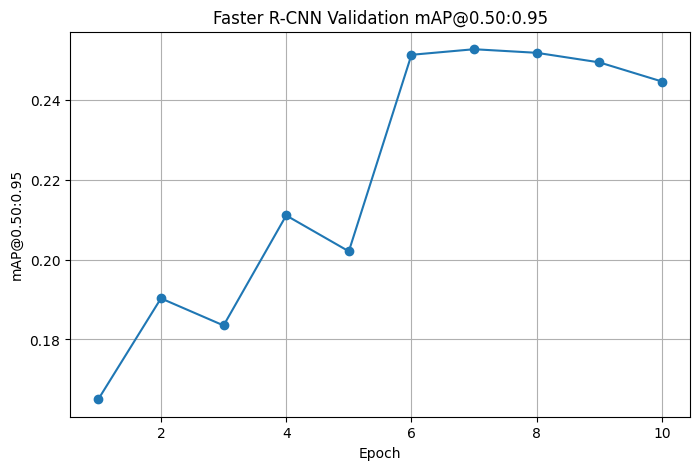

In [29]:
map5095 = [
    0.1650,
    0.1903,
    0.1835,
    0.2111,
    0.2021,
    0.2514,
    0.2528,
    0.2519,
    0.2495,
    0.2447
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    map5095,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("mAP@0.50:0.95")

plt.title("Faster R-CNN Validation mAP@0.50:0.95")

plt.grid(True)

plt.savefig(
    "map5095_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
import os

os.makedirs(
    "prediction_examples",
    exist_ok=True
)

In [31]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/faster_rcnn_epoch_7.pth"
    )
)

model.to(device)
model.eval()

print("Best Faster R-CNN model loaded!")

Best Faster R-CNN model loaded!


In [33]:
def save_prediction_example(
    idx,
    confidence_threshold=0.5
):

    image, target = val_dataset[idx]

    with torch.no_grad():

        prediction = model(
            [image.to(device)]
        )[0]

    img = image.permute(1,2,0).cpu().numpy()

    fig, ax = plt.subplots(
        figsize=(10,8)
    )

    ax.imshow(img)

    # Ground Truth (Green)
    for box, label in zip(
        target["boxes"],
        target["labels"]
    ):

        x1,y1,x2,y2 = box

        rect = patches.Rectangle(
            (x1,y1),
            x2-x1,
            y2-y1,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )

        ax.add_patch(rect)

    # Predictions (Red)
    for box, score, label in zip(
        prediction["boxes"],
        prediction["scores"],
        prediction["labels"]
    ):

        if score < confidence_threshold:
            continue

        x1,y1,x2,y2 = box.cpu()

        rect = patches.Rectangle(
            (x1,y1),
            x2-x1,
            y2-y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1-5,
            f"{CLASS_NAMES[label.item()]} ({score:.2f})",
            color='red',
            fontsize=8,
            bbox=dict(facecolor='white')
        )

    plt.title(
        f"Green = Ground Truth | Red = Prediction"
    )

    plt.axis('off')

    save_path = (
    "/kaggle/working/prediction_examples/"
    f"example_{idx}.png"
)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    print(f"Saved {save_path}")

In [34]:
sample_indices = [
    10,
    50,
    100,
    200,
    500,
    800,
    1000,
    1500,
    1800,
    1999
]

for idx in sample_indices:

    save_prediction_example(idx)

Saved /kaggle/working/prediction_examples/example_10.png
Saved /kaggle/working/prediction_examples/example_50.png
Saved /kaggle/working/prediction_examples/example_100.png
Saved /kaggle/working/prediction_examples/example_200.png
Saved /kaggle/working/prediction_examples/example_500.png
Saved /kaggle/working/prediction_examples/example_800.png
Saved /kaggle/working/prediction_examples/example_1000.png
Saved /kaggle/working/prediction_examples/example_1500.png
Saved /kaggle/working/prediction_examples/example_1800.png
Saved /kaggle/working/prediction_examples/example_1999.png


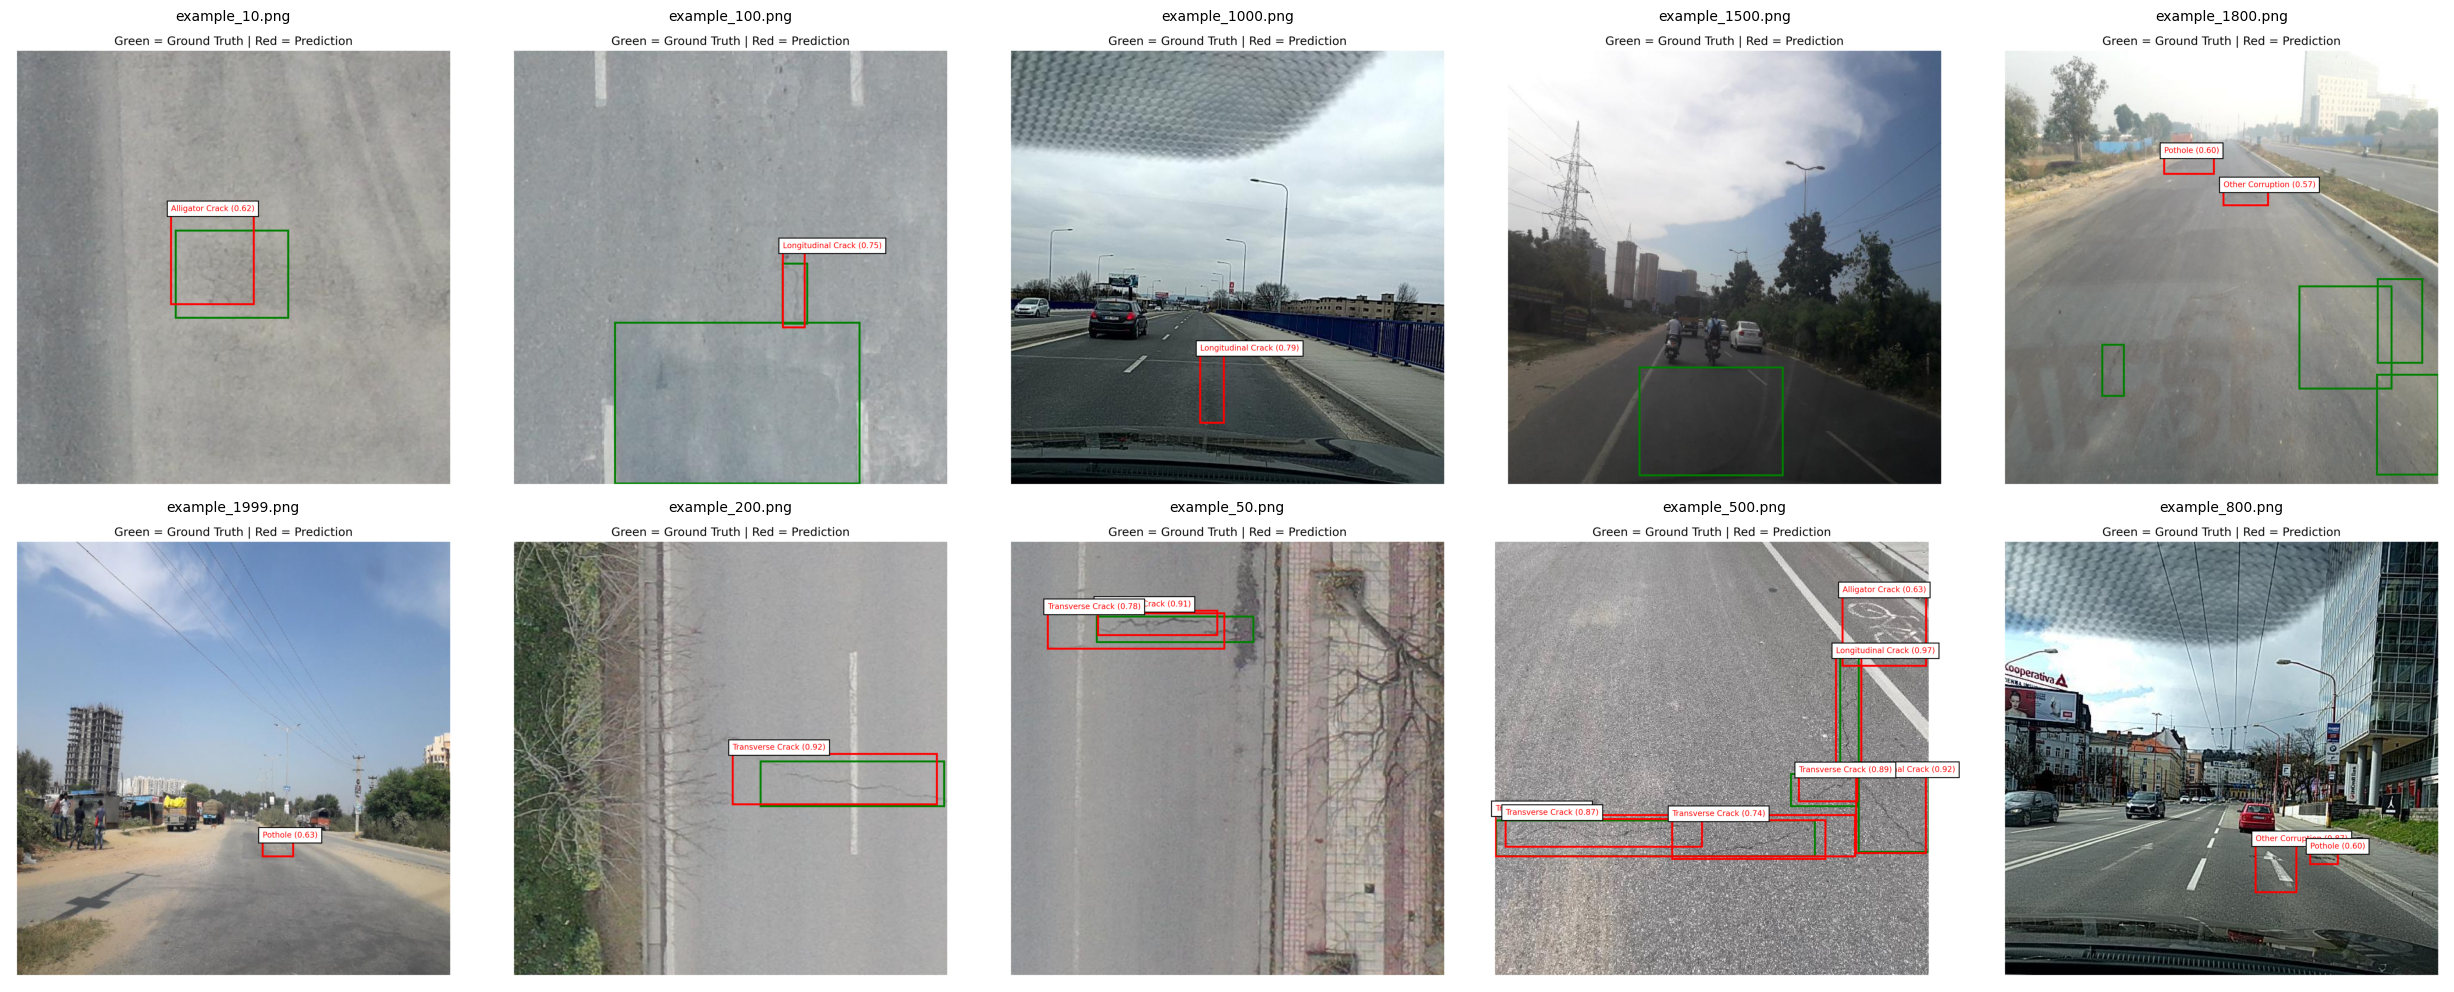

In [35]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder = "/kaggle/working/prediction_examples"

images = sorted(os.listdir(folder))

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for ax, img_name in zip(axes.flatten(), images):

    img_path = os.path.join(folder, img_name)

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(img_name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()